In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
print("Shape:", df.shape)
df.info()
df.describe(include="all").T

Shape: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [3]:
df = df.copy()

for col in ["sex", "smoker", "region"]:
    df[col] = df[col].str.strip().str.lower()

print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
df.to_csv("insurance_cleaned.csv", index=False)

df.shape

Missing values: 0
Duplicate rows: 1


(1337, 7)

In [4]:
df.groupby("smoker")["charges"].agg(["count", "mean", "median"]).round(2)

,count,mean,median
smoker,,,
no,1063,8440.66,7345.73
yes,274,32050.23,34456.35


In [5]:
encoded = pd.get_dummies(df, drop_first=True, dtype=int)

correlation = (
    encoded.corr(numeric_only=True)["charges"]
    .drop("charges")
    .sort_values(key=abs, ascending=False)
)

correlation.to_frame("Correlation with Charges")

,Correlation with Charges
smoker_yes,0.787234
age,0.298308
bmi,0.198401
region_southeast,0.073578
children,0.067389
sex_male,0.058044
region_southwest,-0.043637
region_northwest,-0.038695


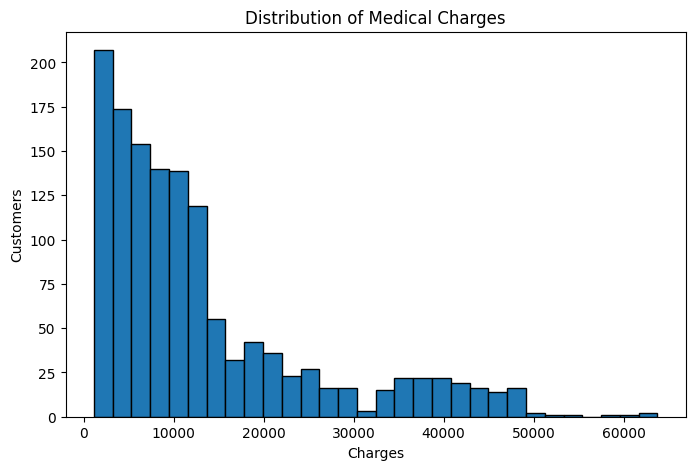

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df["charges"], bins=30, edgecolor="black")
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Customers")
plt.show()

<Figure size 800x500 with 0 Axes>

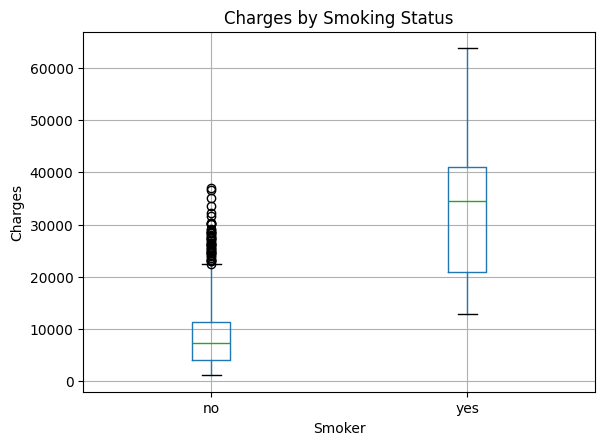

In [7]:
plt.figure(figsize=(8, 5))
df.boxplot(column="charges", by="smoker")
plt.title("Charges by Smoking Status")
plt.suptitle("")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

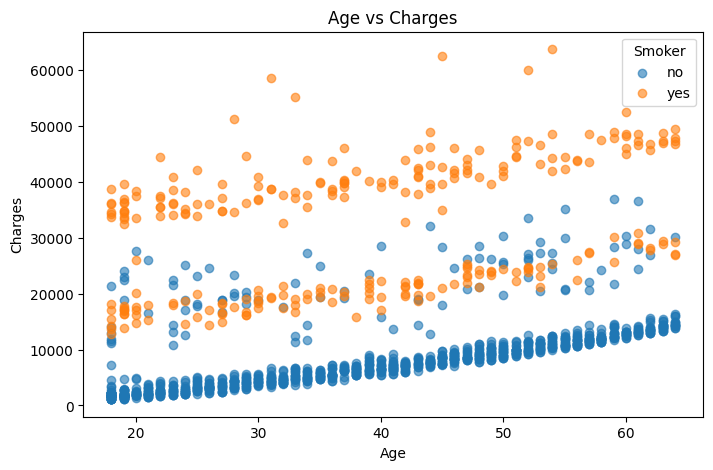

In [8]:
plt.figure(figsize=(8, 5))

for status, group in df.groupby("smoker"):
    plt.scatter(group["age"], group["charges"], alpha=0.6, label=status)

plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.legend(title="Smoker")
plt.show()

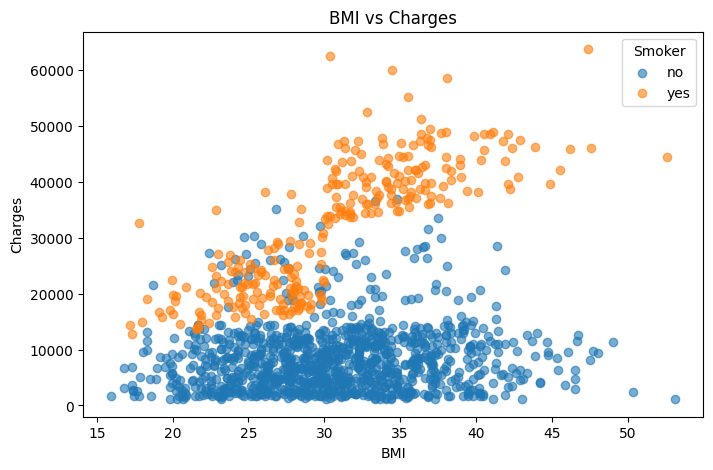

In [9]:
plt.figure(figsize=(8, 5))

for status, group in df.groupby("smoker"):
    plt.scatter(group["bmi"], group["charges"], alpha=0.6, label=status)

plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.legend(title="Smoker")
plt.show()

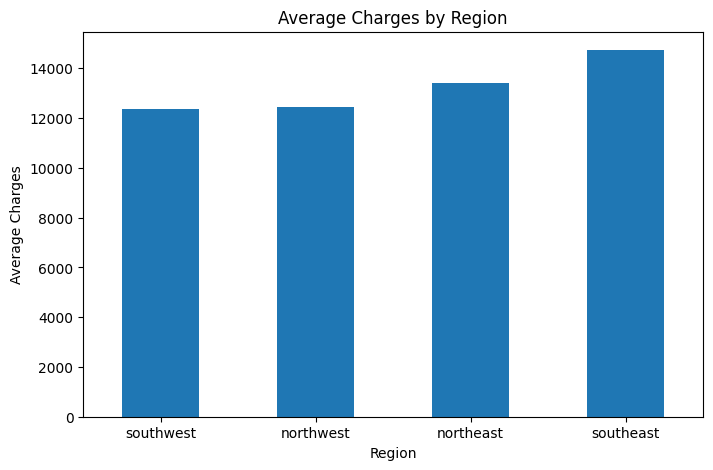

In [10]:
region_mean = df.groupby("region")["charges"].mean().sort_values()

plt.figure(figsize=(8, 5))
region_mean.plot(kind="bar")
plt.title("Average Charges by Region")
plt.xlabel("Region")
plt.ylabel("Average Charges")
plt.xticks(rotation=0)
plt.show()

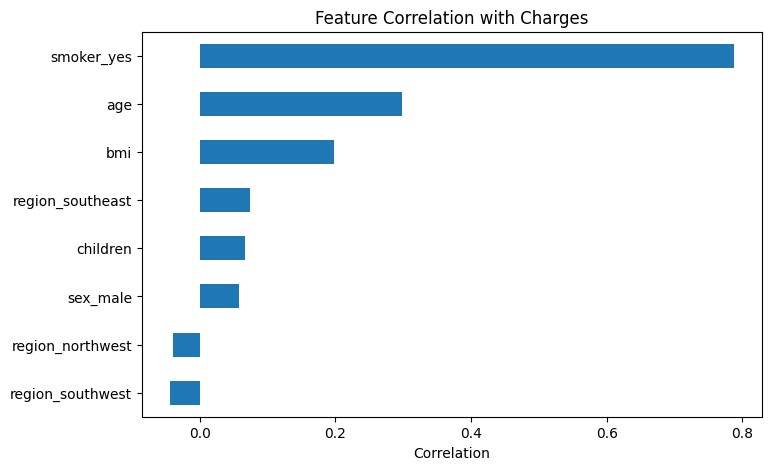

In [11]:
plt.figure(figsize=(8, 5))
correlation.sort_values().plot(kind="barh")
plt.title("Feature Correlation with Charges")
plt.xlabel("Correlation")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = encoded.drop(columns="charges")
y = encoded["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(1069, 8) (268, 8)


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_feature = "smoker_yes"  # confirm this matches your top correlation

X_train_simple = X_train[[best_feature]]
X_test_simple = X_test[[best_feature]]

lr_simple = LinearRegression()
lr_simple.fit(X_train_simple, y_train)
y_pred_simple = lr_simple.predict(X_test_simple)

mae = mean_absolute_error(y_test, y_pred_simple)
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_simple)

results = {}
results["Simple Linear Regression"] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}
results

{'Simple Linear Regression': {'MAE': 5830.635672652305,
  'MSE': 60039304.15008918,
  'RMSE': np.float64(7748.503349040328),
  'R2': 0.673266270349257}}

In [14]:
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)
y_pred_multi = lr_multi.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_multi)
mse = mean_squared_error(y_test, y_pred_multi)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_multi)

results["Multiple Linear Regression"] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}
results

{'Simple Linear Regression': {'MAE': 5830.635672652305,
  'MSE': 60039304.15008918,
  'RMSE': np.float64(7748.503349040328),
  'R2': 0.673266270349257},
 'Multiple Linear Regression': {'MAE': 4177.045561036316,
  'MSE': 35478020.67523557,
  'RMSE': np.float64(5956.342894363585),
  'R2': 0.8069287081198013}}

In [15]:
from sklearn.preprocessing import PolynomialFeatures

for degree in [2, 3, 4]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    lr_poly = LinearRegression()
    lr_poly.fit(X_train_poly, y_train)

    y_train_pred = lr_poly.predict(X_train_poly)
    y_test_pred = lr_poly.predict(X_test_poly)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)

    print(f"Degree {degree}: Train R2={train_r2:.4f}, Test R2={test_r2:.4f}, "
          f"Test MAE={mae:.2f}, Test RMSE={rmse:.2f}")

    results[f"Polynomial Regression (deg {degree})"] = {
        "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": test_r2
    }

Degree 2: Train R2=0.8340, Test R2=0.8825, Test MAE=2867.32, Test RMSE=4646.06
Degree 3: Train R2=0.8471, Test R2=0.8709, Test MAE=3048.86, Test RMSE=4870.27
Degree 4: Train R2=0.8666, Test R2=0.8003, Test MAE=3756.15, Test RMSE=6057.86


In [16]:
from sklearn.linear_model import Ridge

alphas = [0.01, 0.1, 1, 10, 50, 100, 200]
ridge_results = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    ridge_results.append((a, r2))

ridge_results

[(0.01, 0.8069190950361477),
 (0.1, 0.8068324662638852),
 (1, 0.805955350724643),
 (10, 0.7962496939735049),
 (50, 0.7432449595437586),
 (100, 0.676391046472479),
 (200, 0.5704831758727191)]

In [17]:
best_alpha_ridge = 0.01

ridge_final = Ridge(alpha=best_alpha_ridge)
ridge_final.fit(X_train, y_train)
y_pred_ridge = ridge_final.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_ridge)
mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ridge)

results["Ridge Regression"] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}
results

{'Simple Linear Regression': {'MAE': 5830.635672652305,
  'MSE': 60039304.15008918,
  'RMSE': np.float64(7748.503349040328),
  'R2': 0.673266270349257},
 'Multiple Linear Regression': {'MAE': 4177.045561036316,
  'MSE': 35478020.67523557,
  'RMSE': np.float64(5956.342894363585),
  'R2': 0.8069287081198013},
 'Polynomial Regression (deg 2)': {'MAE': 2867.317439475337,
  'MSE': 21585843.72442232,
  'RMSE': np.float64(4646.0567930689695),
  'R2': 0.8825298972468502},
 'Polynomial Regression (deg 3)': {'MAE': 3048.863649155499,
  'MSE': 23719529.85222565,
  'RMSE': np.float64(4870.2699978774945),
  'R2': 0.8709183831510428},
 'Polynomial Regression (deg 4)': {'MAE': 3756.150029059435,
  'MSE': 36697660.84111135,
  'RMSE': np.float64(6057.859427315176),
  'R2': 0.8002914296591407},
 'Ridge Regression': {'MAE': 4177.216221466937,
  'MSE': 35479787.13765106,
  'RMSE': np.float64(5956.4911766619),
  'R2': 0.8069190950361477}}

In [18]:
from sklearn.linear_model import Lasso

alphas = [0.01, 0.1, 1, 10, 50, 100, 200]
lasso_results = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    lasso_results.append((a, r2))

lasso_results

[(0.01, 0.8069280042563021),
 (0.1, 0.8069216664782433),
 (1, 0.8068579520088277),
 (10, 0.8061868740135817),
 (50, 0.8028740093284042),
 (100, 0.8000461394756194),
 (200, 0.7947217487122731)]

In [19]:
best_alpha_lasso = 0.01

lasso_final = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_final.fit(X_train, y_train)
y_pred_lasso = lasso_final.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lasso)
mse = mean_squared_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lasso)

results["Lasso Regression"] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

coef_table = pd.Series(lasso_final.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
print(coef_table)

eliminated = coef_table[coef_table == 0].index.tolist()
print("\nFeatures eliminated by Lasso:", eliminated)

smoker_yes          23077.698352
region_southeast     -838.741126
region_southwest     -658.969491
children              533.003626
region_northwest     -391.595249
bmi                   318.698864
age                   248.210847
sex_male             -101.494993
dtype: float64

Features eliminated by Lasso: []


In [21]:
from sklearn.svm import SVR

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

svr_results_summary = {}

for kernel in ["rbf", "linear"]:
    svr = SVR(kernel=kernel)
    svr.fit(X_train_scaled, y_train_scaled)

    y_pred_scaled = svr.predict(X_test_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    svr_results_summary[kernel] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}
    results[f"SVR ({kernel})"] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

svr_results_summary

{'rbf': {'MAE': 2547.1096204494584,
  'MSE': 22175170.098157484,
  'RMSE': np.float64(4709.051931987742),
  'R2': 0.8793227847261806},
 'linear': {'MAE': 3215.5848693607936,
  'MSE': 37168329.511761,
  'RMSE': np.float64(6096.5834294103615),
  'R2': 0.7977300520354647}}

In [22]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

depths = [2, 3, 4, 5, None]
tree_results_summary = {}

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    tree_results_summary[str(d)] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

tree_results_summary

{'2': {'MAE': 3312.8448982743926,
  'MSE': 24402426.233530518,
  'RMSE': np.float64(4939.881196297186),
  'R2': 0.8672020629040432},
 '3': {'MAE': 2755.269509171695,
  'MSE': 19670972.639684547,
  'RMSE': np.float64(4435.197023772963),
  'R2': 0.8929506204742996},
 '4': {'MAE': 2621.3124045359605,
  'MSE': 18886631.250029117,
  'RMSE': np.float64(4345.875199546015),
  'R2': 0.8972190041804287},
 '5': {'MAE': 2656.8390786583914,
  'MSE': 19461664.316805515,
  'RMSE': np.float64(4411.537636335603),
  'R2': 0.8940896757972968},
 'None': {'MAE': 2730.629848988806,
  'MSE': 33281524.624168295,
  'RMSE': np.float64(5769.014181311075),
  'R2': 0.8188820336469307}}

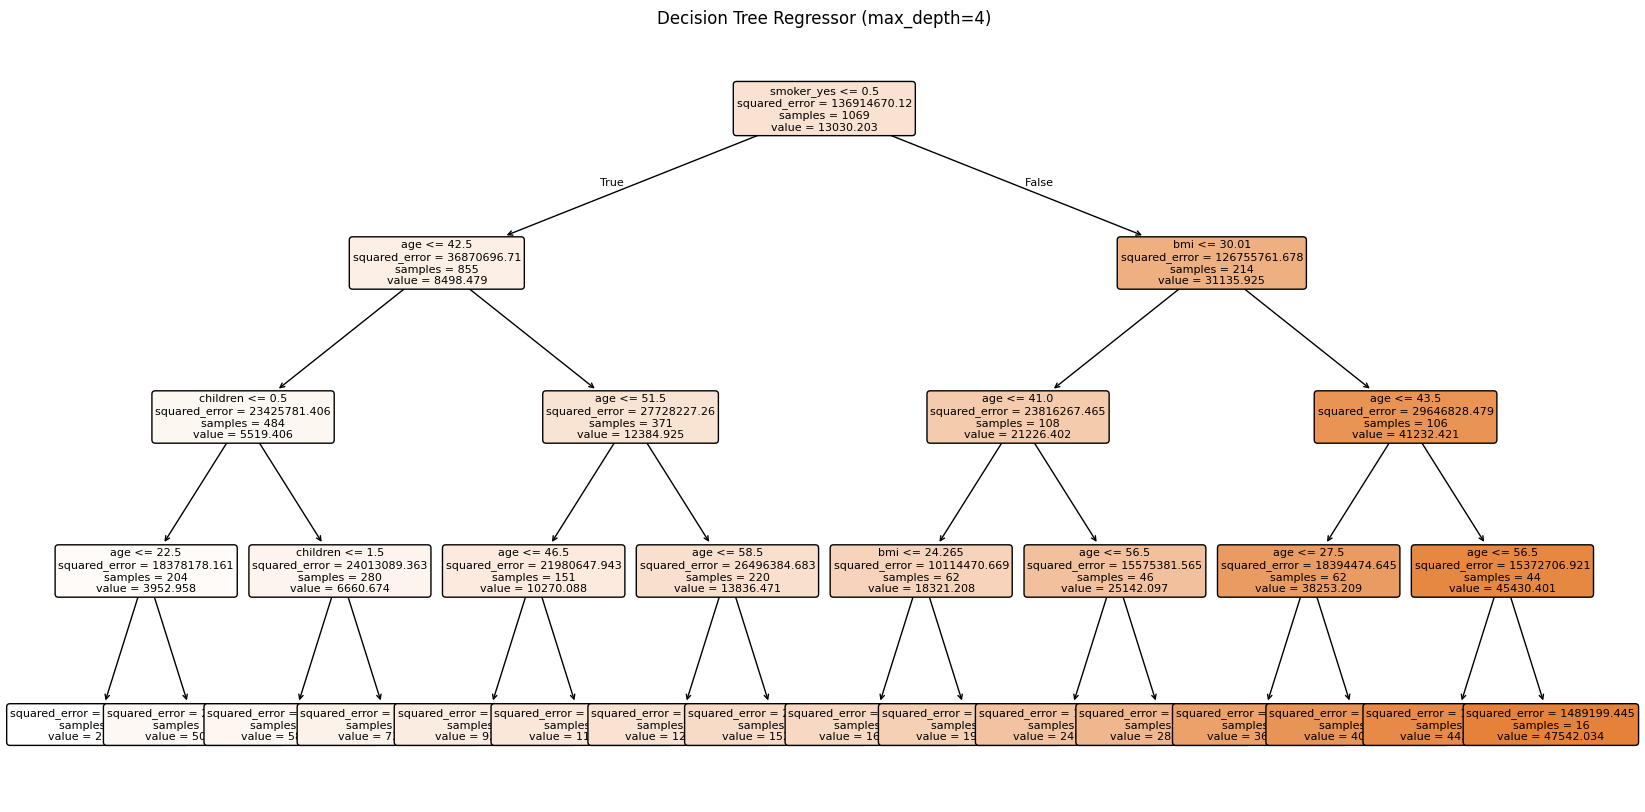

In [23]:
best_depth = 4

tree_final = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
tree_final.fit(X_train, y_train)
y_pred_tree = tree_final.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tree)
mse = mean_squared_error(y_test, y_pred_tree)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_tree)

results["Decision Tree Regression"] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

plt.figure(figsize=(20, 10))
plot_tree(tree_final, feature_names=X_train.columns, filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree Regressor (max_depth=4)")
plt.show()

In [24]:
summary_table = pd.DataFrame(results).T
summary_table = summary_table.sort_values("R2", ascending=False)
summary_table

,MAE,MSE,RMSE,R2
Decision Tree Regression,2621.312405,1.888663e+07,4345.875200,0.897219
Polynomial Regression (deg 2),2867.317439,2.158584e+07,4646.056793,0.882530
SVR (rbf),2547.109620,2.217517e+07,4709.051932,0.879323
Polynomial Regression (deg 3),3048.863649,2.371953e+07,4870.269998,0.870918
Multiple Linear Regression,4177.045561,3.547802e+07,5956.342894,0.806929
Lasso Regression,4177.054040,3.547815e+07,5956.353752,0.806928
Ridge Regression,4177.216221,3.547979e+07,5956.491177,0.806919
Polynomial Regression (deg 4),3756.150029,3.669766e+07,6057.859427,0.800291
SVR (linear),3215.584869,3.716833e+07,6096.583429,0.797730
Simple Linear Regression,5830.635673,6.003930e+07,7748.503349,0.673266


In [25]:
#Requirement-3

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

median_charge = df["charges"].median()
print("Median charge:", median_charge)

y_class = (encoded["charges"] > median_charge).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print(y_class.value_counts())

Median charge: 9386.1613
charges
0    669
1    668
Name: count, dtype: int64


In [26]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_c, y_train_c)
y_pred_lr = log_reg.predict(X_test_c)

class_results = {}
class_results["Logistic Regression"] = {
    "Accuracy": accuracy_score(y_test_c, y_pred_lr),
    "Precision": precision_score(y_test_c, y_pred_lr),
    "Recall": recall_score(y_test_c, y_pred_lr),
    "F1": f1_score(y_test_c, y_pred_lr),
}

print(class_results["Logistic Regression"])
print(confusion_matrix(y_test_c, y_pred_lr))

{'Accuracy': 0.9067164179104478, 'Precision': 0.8978102189781022, 'Recall': 0.917910447761194, 'F1': 0.9077490774907749}
[[120  14]
 [ 11 123]]


In [27]:
from sklearn.tree import DecisionTreeClassifier

depths = [2, 3, 4, 5, None]
tree_class_summary = {}

for d in depths:
    tree_c = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree_c.fit(X_train_c, y_train_c)
    y_pred = tree_c.predict(X_test_c)
    tree_class_summary[str(d)] = accuracy_score(y_test_c, y_pred)

tree_class_summary

{'2': 0.9253731343283582,
 '3': 0.9328358208955224,
 '4': 0.9365671641791045,
 '5': 0.9402985074626866,
 'None': 0.9104477611940298}

In [28]:
best_depth_class = 5

tree_c_final = DecisionTreeClassifier(max_depth=best_depth_class, random_state=42)
tree_c_final.fit(X_train_c, y_train_c)
y_pred_tree_c = tree_c_final.predict(X_test_c)

class_results["Decision Tree Classifier"] = {
    "Accuracy": accuracy_score(y_test_c, y_pred_tree_c),
    "Precision": precision_score(y_test_c, y_pred_tree_c),
    "Recall": recall_score(y_test_c, y_pred_tree_c),
    "F1": f1_score(y_test_c, y_pred_tree_c),
}

print(class_results["Decision Tree Classifier"])
print(confusion_matrix(y_test_c, y_pred_tree_c))

class_summary_table = pd.DataFrame(class_results).T
class_summary_table

{'Accuracy': 0.9402985074626866, 'Precision': 0.9916666666666667, 'Recall': 0.8880597014925373, 'F1': 0.937007874015748}
[[133   1]
 [ 15 119]]


,Accuracy,Precision,Recall,F1
Logistic Regression,0.906716,0.897810,0.91791,0.907749
Decision Tree Classifier,0.940299,0.991667,0.88806,0.937008


In [ ]:
...